### Learning Normalizing flows from samples with PyTorch

Mathematical description: Learn the map by minimizing the negative log-likelihood of the $N$ samples:
\begin{equation}
    \newcommand{\bftheta}{\boldsymbol{\theta}}
    \newcommand{\bfx}{\mathbf{x}}
    \newcommand{\bfz}{\mathbf{z}}
    \newcommand{\bfy}{\mathbf{y}}
\min_{\bftheta}  \frac{1}{N} \sum_{i=1}^N \left( {\frac{1}{2}}\left\| T_{\bftheta}^{-1}\left(\bfx^{i}\right)\right\|^2 - \log\det\nabla  T_{\bftheta}^{-1}\left(\bfx^{i}\right) \right),
\end{equation}
where $\bfx^{1}, \ldots, \bfx^{N}$ are sampled i.i.d. from the data distribution. Here, we will use a map of the form
\begin{equation*}
    T_{\bftheta}(\bfz) = L_K \circ L_{K-1} \circ \cdots \circ L_1(\bfz),
\end{equation*}
where each $L_j \colon \mathbb{R}^d \rightarrow \mathbb{R}^d$ is invertible to obtain a tractable inverse and log-determinant.

In [6]:
import torch
from torch import nn
import numpy as np
from torch import distributions
from sklearn import datasets
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'font.size': 16})

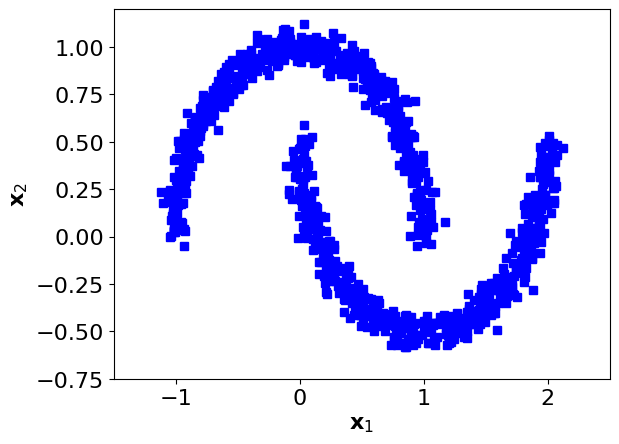

In [2]:
def get_data(batch_size,noise=0.05):
    return torch.tensor(datasets.make_moons(n_samples=batch_size, noise=noise)[0], dtype=torch.float32)

# get samples
xs = get_data(1000)
domain = [-5,10]

# define grid
domain_x1 = [-1.5,2.5]
domain_x2 = [-0.75,1.2]

plt.figure()
plt.plot(xs[:, 0], xs[:, 1], "bs")
plt.xlim(domain_x1)
plt.ylim(domain_x2)
plt.xlabel("$\mathbf{x}_1$")
plt.ylabel("$\mathbf{x}_2$")
plt.show()

## Define model

\begin{equation*}
    \newcommand{\bftheta}{\boldsymbol{\theta}}
	\newcommand{\bfz}{\mathbf{z}}
	\newcommand{\bfy}{\mathbf{y}}
	\newcommand{\bfm}{\mathbf{m}}
\end{equation*}
Here we are using the Real NVP layer in the map $T_\theta$

\begin{equation*}
L_j\left(\bfy^{(j)}\right) = \bfm^{(j)} \odot \bfy^{(j)} + (1-\bfm^{(j)}) \odot \left(y^{(j)} \odot \exp\left(b( \bfy^{(j)} \odot \bfm^{(j)})\right) + a\left(\bfy^{(j)} \odot \bfm^{(j)}\right)\right),
\end{equation*}

where $\bfm^{j} \in \{0,1\}^n$ is used to mask some components of the inputs. Below, we alternate between the first and second coordinate.

In [3]:
#RealNVP class

class RealNVP(nn.Module):
    def __init__(self, nets, nett, mask, ref):
        super(RealNVP, self).__init__()

        self.ref = ref
        self.mask = nn.Parameter(mask, requires_grad=False)
        self.a = torch.nn.ModuleList([nett() for _ in range(len(masks))])
        self.b = torch.nn.ModuleList([nets() for _ in range(len(masks))])

    def T(self, z):
        x = z
        for i in range(len(self.a)):
            x_ = x*self.mask[i]
            b = self.b[i](x_)*(1 - self.mask[i])
            a = self.a[i](x_)*(1 - self.mask[i])
            x = x_ + (1 - self.mask[i]) * (x * torch.exp(b) + a)
        return x

    def Tinv(self, x):
        log_det_J, z = x.new_zeros(x.shape[0]), x
        for i in reversed(range(len(self.a))):
            z_ = self.mask[i] * z
            b = self.b[i](z_) * (1-self.mask[i])
            a = self.a[i](z_) * (1-self.mask[i])
            z = (1 - self.mask[i]) * (z - a) * torch.exp(-b) + z_
            log_det_J -= b.sum(dim=1)
        return z, log_det_J

    def log_prob(self,x):
        z, logdet = self.Tinv(x)
        return self.ref.log_prob(z) + logdet

    def sample(self, batchSize):
        z = self.ref.sample((batchSize, 1))
        logp = self.ref.log_prob(z)
        x = self.T(z)
        return x


## Train model

In [4]:
batch_size     = 64         # number of samples at each step
num_steps      = 5000       # number of training steps
print_interval = 20         # interval for visualizing intermediate results

# define model
K = 3
netb  = lambda: nn.Sequential(nn.Linear(2, 256), nn.LeakyReLU(), nn.Linear(256, 256), nn.LeakyReLU(), nn.Linear(256, 2), nn.Tanh())
neta  = lambda: nn.Sequential(nn.Linear(2, 256), nn.LeakyReLU(), nn.Linear(256, 256), nn.LeakyReLU(), nn.Linear(256, 2))
masks = torch.from_numpy(np.array([[0, 1], [1, 0]] * K).astype(np.float32))
eta   = distributions.MultivariateNormal(torch.zeros(2), torch.eye(2))
flow  = RealNVP(netb, neta, masks, eta)

# define optimizer
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4)

# define array for negative log-likelihood
his_nll = np.zeros((0,1))

print((2*"%6s   ") % ("step","J_NF"))

train_JML = 0.0
num_step = 0

# grid of the spatial domain (for plotting)
domain_x1 = [-1.5,2.5]
domain_x2 = [-0.75,1.2]
x1 = torch.linspace(domain_x1[0],domain_x1[1], 100)
x2 = torch.linspace(domain_x2[0],domain_x2[1], 100)
xg = torch.meshgrid(x1, x2)
xx = torch.cat((xg[0].reshape(-1, 1), xg[1].reshape(-1, 1)), 1)

for step in range(num_steps):

    # evaluate loss function
    x = get_data(batch_size)
    loss = -flow.log_prob(x).mean()

    # take gradient step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # store loss function
    train_JML += loss.item()
    num_step += 1

    # print loss and plot results
    if (step + 1) % print_interval == 0:
        train_JML /= num_step
        print(("%06d   " + "%1.4e  ") %
              (step + 1, train_JML))
        his_nll = np.vstack([his_nll, [train_JML]])
        train_JML = 0.0
        num_step = 0

        # evaluate and plot density
        log_px = flow.log_prob(xx).detach()
        plt.figure()
        plt.plot(x[:,0],x[:,1],'.b')
        plt.contourf(xg[0],xg[1],torch.exp(log_px.reshape(len(x1), len(x2))))
        plt.show()


Output hidden; open in https://colab.research.google.com to view.

## Check the final result

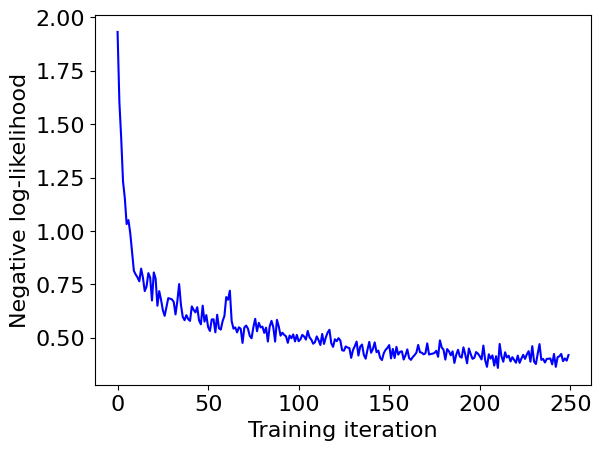

In [5]:
## Check convergence
plt.figure()
plt.plot(his_nll,'-b')
plt.xlabel('Training iteration')
plt.ylabel('Negative log-likelihood')
plt.show()

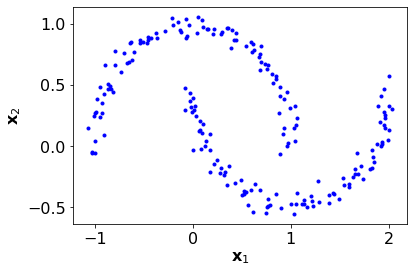

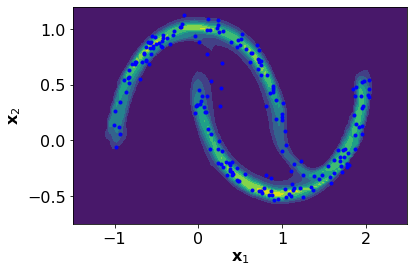

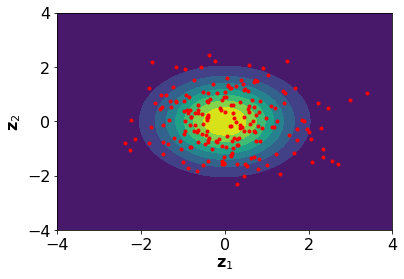

In [ ]:
# generate test samples
Ntest = 200
xtest = get_data(Ntest)

# grid of the spatial domain (for plotting)
domain_x1 = [-1.5,2.5]
domain_x2 = [-0.75,1.2]
x1 = torch.linspace(domain_x1[0],domain_x1[1], 100)
x2 = torch.linspace(domain_x2[0],domain_x2[1], 100)
xg = torch.meshgrid(x1, x2)
xx = torch.cat((xg[0].reshape(-1, 1), xg[1].reshape(-1, 1)), 1)

# evaluate log-probability and sample model
log_px = flow.log_prob(xx).detach()
xs = flow.sample(Ntest).detach()

#plt.figure(figsize=(15,4))
#plt.subplot(1,2,1)
plt.figure()
plt.plot(xtest[:,0],xtest[:,1],'.b')
plt.xlabel("$\mathbf{x}_1$")
plt.ylabel("$\mathbf{x}_2$")
#plt.title("Training samples")
plt.savefig('figures/Moons_training_data.png')
plt.show()

plt.figure()
plt.contourf(xg[0],xg[1],torch.exp(log_px.reshape(len(x1), len(x2))))
plt.plot(xs[:,0,0],xs[:,0,1],'.b')
#plt.title("Approximate density and generator samples")
plt.xlabel("$\mathbf{x}_1$")
plt.ylabel("$\mathbf{x}_2$")
plt.savefig('figures/Moons_approximation.png')
plt.show()

# grid of the spatial domain (for plotting reference)
domain_z1 = [-4,4]
domain_z2 = [-4,4]
z1 = torch.linspace(domain_z1[0],domain_z1[1], 100)
z2 = torch.linspace(domain_z2[0],domain_z2[1], 100)
zg = torch.meshgrid(z1, z2)
zz = torch.cat((zg[0].reshape(-1, 1), zg[1].reshape(-1, 1)), 1)

# evaluate density of latent distribution and sample latent space
log_pz = flow.ref.log_prob(zz).detach()
zs = flow.Tinv(xs[:,0,:])[0].detach().numpy()

plt.figure()
plt.contourf(zg[0],zg[1],torch.exp(log_pz.reshape(len(x1), len(x2))))
plt.plot(zs[:,0],zs[:,1],'.r')
#plt.title("Inverse of generator $T_{\\theta}^{-1}(\mathbf{z})$ samples")
plt.xlabel("$\mathbf{z}_1$")
plt.ylabel("$\mathbf{z}_2$")
plt.xlim(domain_z1)
plt.ylim(domain_z2)
plt.savefig('figures/Moons_latent.png')
plt.show()

# Some suggested experiments to try:

1. Vary the hyper-parameters (number of layers K, width of networks and learning rate) and see how they perform
2. Reduce the width of the moons dataset so that the intrinsic dimensionality reduces to 1
3. Try other datasets (e.g., uniform target $\pi$) or create your own